# The thermal environment: when one temperature is not enough

Every BBR notebook so far in this project has treated a clock's radiation
environment as a single number, one temperature, uniform across every
surface the atoms can see. A lab willing to build a dedicated shield, PTB's
cooled copper enclosure or NIST Yb's carbon-nanotube-coated interior, can
make that number close to exact, because an actively controlled enclosure
genuinely does hold every visible surface near the same setpoint. A clock
riding in a vehicle, or sitting behind a viewport that a diurnal cycle or a
nearby heat source can warm relative to the surrounding chamber, cannot make
that promise, and the reduction from many surfaces to one effective
temperature stops being a convenience and starts being an approximation with
a computable error. That error is exact for the static BBR term by
construction, because any single temperature chosen to match the
environment's true `T^4`-weighted average reproduces the static term
exactly, but the dynamic term is a separate polynomial in `T^6` through
`T^10`, and raising a weighted average to a higher power is not the same
operation as weighting the higher power directly. E37
(`docs/CONVENTIONS.md` section 13, gated at G10) replaces the single
temperature with an explicit multi-surface description and evaluates both
terms against the environment's own per-moment sums, so this notebook can
compute the resulting mismatch directly instead of arguing about its size.

**Status: pre-beta research code.**

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np

from cliffordclock.ensemble.species import get_species
from cliffordclock.integrator.omega import (
    RadiationSurface,
    _bbr_effective_weights,
    bbr_environment_effective_temperatures,
    bbr_environment_pivot_perturbation,
    bbr_environment_pivot_uncertainty,
    bbr_pivot_perturbation,
)

_notebook_start_s = time.time()
np.set_printoptions(precision=6, suppress=False)
sr87 = get_species("Sr87")
print(f"species: Sr87, clock frequency nu_0 = {sr87.clock_frequency_hz:.6f} Hz")

species: Sr87, clock frequency nu_0 = 429228004229873.375000 Hz


## 1. The moment mismatch, quantified live

E32's single temperature is always the `<T^4>`-matched effective temperature
of whatever real environment it stands in for: for a set of surfaces at
solid-angle fractions `w_i` and temperatures `T_i`, choosing
`T_eff = (sum_i w_i T_i^4)^(1/4)` reproduces the static term exactly by
construction. The dynamic term enjoys no such guarantee, because
`sum_i w_i T_i^n` for `n = 6, 8, 10` is generally not equal to `T_eff^n`.
The cells below sweep the temperature spread between two surfaces for two
geometries, a 50/50 split (two walls of comparable size) and a 10/90 split
(one small viewport against a large chamber body), evaluate the exact E37
shift and the `T^4`-matched single-temperature E32 approximation at every
spread, and report where their difference crosses two thresholds that
matter for clock accuracy: `1e-18`, close to a modern lattice clock's total
systematic budget, and `1e-17`, an order of magnitude above it.

In [2]:
def single_t_mismatch(f, spread_k, species, center_k=300.0):
    """|exact E37 shift - T^4-matched single-T E32 shift| for a two-surface
    environment: fraction f at (center - spread/2), fraction (1-f) at
    (center + spread/2)."""
    t1 = center_k - spread_k / 2.0
    t2 = center_k + spread_k / 2.0
    surfaces = (
        RadiationSurface(name="t1", weight=f, temperature_k=t1),
        RadiationSurface(name="t2", weight=1.0 - f, temperature_k=t2),
    )
    exact = bbr_environment_pivot_perturbation(surfaces, species)
    t_eff_static = (f * t1**4 + (1.0 - f) * t2**4) ** 0.25
    approx = bbr_pivot_perturbation(t_eff_static, species)
    return abs(exact - approx)


def find_crossings(f, thresholds, species, spreads_k):
    mismatches = np.array([single_t_mismatch(f, s, species) for s in spreads_k])
    crossings = {}
    for thresh in thresholds:
        idx = np.searchsorted(mismatches, thresh)
        if 0 < idx < len(spreads_k):
            s0, s1 = spreads_k[idx - 1], spreads_k[idx]
            v0, v1 = mismatches[idx - 1], mismatches[idx]
            crossings[thresh] = s0 + (thresh - v0) * (s1 - s0) / (v1 - v0)
        else:
            crossings[thresh] = None
    return mismatches, crossings


SPREADS_K = np.linspace(0.1, 100.0, 4000)
THRESHOLDS = (1e-18, 1e-17)
SCENARIOS = {"50/50 split": 0.5, "10/90 split (viewport vs. chamber)": 0.1}

sweep_results = {}
for label, f in SCENARIOS.items():
    mismatches, crossings = find_crossings(f, THRESHOLDS, sr87, SPREADS_K)
    sweep_results[label] = (f, mismatches, crossings)
    print(f"{label} (f = {f}):")
    for thresh, spread in crossings.items():
        if spread is not None:
            print(f"  crosses {thresh:.0e} at a spread of {spread:.2f} K")
        else:
            print(f"  does not cross {thresh:.0e} within the scanned range")
    print()

50/50 split (f = 0.5):
  crosses 1e-18 at a spread of 11.13 K
  crosses 1e-17 at a spread of 35.12 K

10/90 split (viewport vs. chamber) (f = 0.1):
  crosses 1e-18 at a spread of 18.60 K
  crosses 1e-17 at a spread of 58.84 K



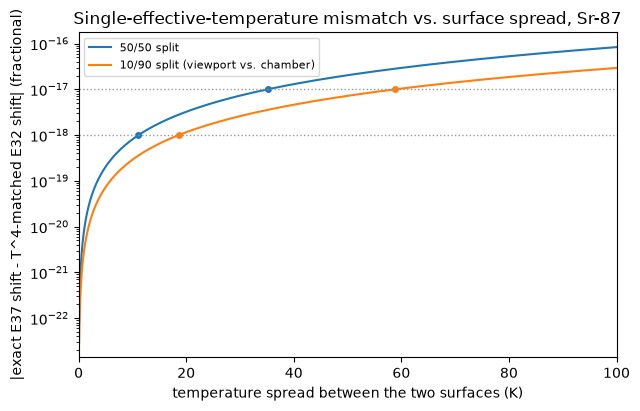

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
colors = {"50/50 split": "C0", "10/90 split (viewport vs. chamber)": "C1"}
for label, (f, mismatches, crossings) in sweep_results.items():
    ax.plot(SPREADS_K, mismatches, color=colors[label], label=label)
    for spread in crossings.values():
        if spread is not None:
            ax.plot(
                spread,
                single_t_mismatch(f, spread, sr87),
                "o",
                color=colors[label],
                markersize=4,
            )
for thresh in THRESHOLDS:
    ax.axhline(thresh, color="0.6", linestyle=":", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("temperature spread between the two surfaces (K)")
ax.set_ylabel("|exact E37 shift - T^4-matched E32 shift| (fractional)")
ax.set_title("Single-effective-temperature mismatch vs. surface spread, Sr-87")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

The crossing spreads the live sweep finds, about 11 K and 35 K for the
50/50 split and about 19 K and 59 K for the 10/90 split, are the same
arithmetic run against the same Sr-87 registry coefficients this project's
internal thermal-environment research dossier derived by hand, so they land
on the same numbers by construction, not by coincidence. At lab-grade
spreads, a shielded enclosure held to millikelvin uniformity, the mismatch
sits many orders of magnitude below either threshold and the
single-temperature reduction is exact for every practical purpose. At
field-deployment spreads, tens of kelvin between a sunlit viewport and the
surrounding chamber body, or across a diurnal cycle without active control,
the mismatch crosses both clock-relevant thresholds outright, and E37's
per-moment evaluation makes that error visible directly, instead of absorbing
it silently into a single number. The one caveat this section carries: the
sweep fixes a 300 K center and a symmetric two-surface split to match the
dossier's own scenarios and keep the comparison legible, not because either
choice is the only geometry a field unit could show.

## 2. Validation anchor 1: the PTB aperture model

Nosske et al.'s transportable strontium clock (arXiv:2507.14030, the same
paper already anchoring this project's Sr-87 dynamic-term coefficients)
interrogates atoms inside a cooled, high-emissivity copper shield pierced by
small apertures, and publishes the exact weight arithmetic a simulator
needs: for one aperture of raw solid-angle fraction `w = Omega/4pi` and
shield interior emissivity `epsilon`, the effective fraction of
room-temperature radiation reaching the atoms is
`Omega_eff/4pi = 1 / [1 + (4pi/Omega - 1) epsilon]`, equivalently
`w_eff = w / (w + (1 - w) epsilon)`. E37's `_bbr_effective_weights`
implements this same formula for a single reflective enclosure plus one or
more apertures (`docs/CONVENTIONS.md` E37; this project's independent
review record, G10, closed a blocker on an earlier draft of this exact
reduction and re-verified it against fresh, self-chosen numbers). The cell
below evaluates both forms side by side at an illustrative round-number
check of this project's own choosing (the paper itself publishes only
its apparatus values, which appear in the second row)
and at PTB's actual near-cryogenic operating parameters.

In [4]:
def ptb_closed_form(w, epsilon):
    """Nosske et al. (arXiv:2507.14030) Eq. 3: Omega_eff/4pi for one aperture."""
    return 1.0 / (1.0 + (1.0 / w - 1.0) * epsilon)


def engine_effective_weight(w, epsilon):
    """The engine's own aperture/shield effective weight, via the public
    RadiationSurface + _bbr_effective_weights path (CONVENTIONS.md E37)."""
    surfaces = (
        RadiationSurface(name="aperture", weight=w, temperature_k=300.0),
        RadiationSurface(name="shield", weight=1.0 - w, temperature_k=100.0, emissivity=epsilon),
    )
    weights_eff = _bbr_effective_weights(surfaces)
    return weights_eff[0]  # the aperture's effective weight


PTB_POINTS = [
    ("illustrative round-number check (this project's)", 0.1, 0.5),
    ("PTB's actual cryogenic-shield aperture", 1.17e-3, 0.926),
]

print(
    f"{'case':42s} {'w':>10s} {'epsilon':>9s} {'PTB closed form':>18s}"
    f" {'engine':>16s} {'abs diff':>10s}"
)
for label, w, epsilon in PTB_POINTS:
    ptb_val = ptb_closed_form(w, epsilon)
    eng_val = engine_effective_weight(w, epsilon)
    print(
        f"{label:42s} {w:10.6f} {epsilon:9.3f} {ptb_val:18.12f} {eng_val:16.12f} "
        f"{abs(ptb_val - eng_val):10.2e}"
    )

print()
worked_example_surfaces = (
    RadiationSurface(name="shield", weight=0.9, temperature_k=100.0, emissivity=0.5),
    RadiationSurface(name="aperture", weight=0.1, temperature_k=300.0),
)
worked_example_shift = bbr_environment_pivot_perturbation(worked_example_surfaces, sr87)
print(
    f"(P-1)_BBR, illustrative check (shield 100 K / eps=0.5, aperture 300 K): "
    f"{worked_example_shift:+.6e}"
    f""
)

case                                                w   epsilon    PTB closed form           engine   abs diff
illustrative round-number check (this project's)   0.100000     0.500     0.181818181818   0.181818181818   0.00e+00
PTB's actual cryogenic-shield aperture       0.001170     0.926     0.001263380795   0.001263380795   0.00e+00

(P-1)_BBR, illustrative check (shield 100 K / eps=0.5, aperture 300 K): -1.017663e-15


The two columns land within floating-point roundoff at every point checked,
including PTB's actual near-1e-3 aperture fraction, because E37's
enclosure-and-apertures topology is derived to reduce to this exact formula
for one aperture, not fit to it. What this validates is narrower than a
shift reproduction: it confirms the paper's closed-form weight arithmetic is
transcribed correctly and that the engine's multi-surface evaluation reduces
to it exactly, not that a full shield-temperature reconstruction of PTB's
own chamber has been reproduced end to end. PTB's own shield-body
finite-element simulation and its position-scan validation (a measured
differential shift of `-3.33(3)e-15` against a model prediction of
`-3.32(7)e-15`) are not published as a machine-readable temperature set this
project could replay, so this section's claim stops at formula
transcription, a real but strictly weaker statement than the reproducibility
cases notebooks 06 and 09 make against NPL's and Bothwell's own measured
numbers.

## 3. Validation anchor 2: the JILA temperature-step check

During the January-March 2025 BACON frequency-ratio comparison, JILA's Sr1
team deliberately dropped the clock's operating temperature by 2.5 degrees
Celsius on one comparison day, from 22.1 C to 19.6 C, and used the predicted
change in the BBR correction as a live check on the registry formula's own
temperature dependence (A. Aeppli, PhD thesis, University of Colorado
Boulder (2025), Appendix B; apparatus described in Aeppli et al., PRL 133,
023401 (2024)). This is a single-point consistency anchor, not a spatial
validation: it tests whether E32's `T` dependence tracks a real,
deliberately introduced temperature step, using the same registry
coefficients this notebook has used throughout. The cell below computes the
same predicted change with `bbr_pivot_perturbation` at the two operating
temperatures.

In [5]:
T_HIGH_K = 22.1 + 273.15  # nominal operating temperature
T_LOW_K = 19.6 + 273.15  # the deliberately dropped temperature

shift_high = bbr_pivot_perturbation(T_HIGH_K, sr87)
shift_low = bbr_pivot_perturbation(T_LOW_K, sr87)
predicted_delta = shift_low - shift_high

print(f"T_high (22.1 C):  {T_HIGH_K:.2f} K   (P-1)_BBR = {shift_high:+.6e}")
print(f"T_low  (19.6 C):  {T_LOW_K:.2f} K   (P-1)_BBR = {shift_low:+.6e}")
print()
print(f"predicted change, low minus high:  {predicted_delta:+.3e}")
print(f"part-in-50 characterization on this predicted change: {abs(predicted_delta) / 50.0:.2e}")

# Cross-check with the thesis's own locally fit dynamic polynomial
# (Aeppli 2025, Eq. 6.5: eta_6 = -0.132606, eta_8 = -0.011413,
# eta_10 = -0.009013 Hz; same Middelmann static term), evaluated with
# the identical E32 structure, so the two coefficient sets can be
# compared on this exact prediction.
NU0 = sr87.clock_frequency_hz
STATIC_HZ = -2.13023
THESIS_ETA = {6: -0.132606, 8: -0.011413, 10: -0.009013}


def thesis_bbr(t_k: float) -> float:
    x = t_k / 300.0
    dyn = sum(eta * x**n for n, eta in THESIS_ETA.items())
    return (STATIC_HZ * x**4 + dyn) / NU0


thesis_delta = thesis_bbr(T_LOW_K) - thesis_bbr(T_HIGH_K)
print(f"thesis-polynomial predicted change (low minus high):   {thesis_delta:+.6e}")
print(f"registry-polynomial predicted change (low minus high): {predicted_delta:+.6e}")
print(f"coefficient-set difference on this prediction: {abs(thesis_delta - predicted_delta):.1e}")

T_high (22.1 C):  295.25 K   (P-1)_BBR = -4.978068e-15
T_low  (19.6 C):  292.75 K   (P-1)_BBR = -4.805397e-15

predicted change, low minus high:  +1.727e-16
part-in-50 characterization on this predicted change: 3.45e-18
thesis-polynomial predicted change (low minus high):   +1.726673e-16
registry-polynomial predicted change (low minus high): +1.726712e-16
coefficient-set difference on this prediction: 3.9e-21


The engine's live delta comes out at `1.7e-16` in magnitude. The thesis
quotes its own predicted change as approximately `2e-16`, which is the
same number at one significant digit: the cell above evaluates the
thesis's own locally fit polynomial beside this registry's, and the two
coefficient sets agree on this prediction to a few parts in `1e-21`. The published confirmation is the
clock ratio itself: Aeppli's thesis reports the measured ratio held steady
to better than `4e-18` across the temperature step, which the thesis states
leads to a direct characterization of the BBR correction's temperature
scaling to approximately a part in 50. A part in 50 on a `1.7e-16` predicted
change is about `3e-18`, comparable to the thesis's own `4e-18` clock-ratio
floor, so this is a coarse, order-of-magnitude confirmation of the formula's
temperature dependence, not a high-precision one. It is also a single
operating point, one temperature step on one platform, and says nothing
about spatial non-uniformity: section 2 above is this notebook's validation
anchor for the multi-surface machinery, this section anchors the
temperature-dependence formula alone.

## 4. The field-deployment sensitivity band

A transportable clock without lab-grade thermal engineering does not get
PTB's cooled copper shield or NIST Yb's carbon-nanotube-coated enclosure;
what it typically has is a handful of contact-thermometer readings on real
surfaces, each with its own calibration uncertainty. The scenario below is a
plausible field enclosure: a chamber body at 296 K covering 87% of the
atoms' solid angle, a warm window at 320 K covering 8% (sunlight, or a
nearby electronics enclosure), and a cooler window at 285 K covering the
remaining 5%, with sensor uncertainties of 0.5 to 2 K per surface, well
within what an uncooled RTD or thermistor on a field unit can deliver.
`bbr_environment_pivot_uncertainty` propagates those three sensor
uncertainties into a band on the shift in two modes, independent
(uncorrelated sensor noise) and correlated (a shared calibration-chain error
moving every sensor together, the same motivation Aeppli's thesis gives for
its own linear-pooling combination), and
`bbr_environment_effective_temperatures` reports the per-moment effective
temperatures directly, so the divergence between `T_eff,4` and `T_eff,6` is
a real printed number, not an abstract claim.

In [6]:
SCENARIO_SURFACES = (
    RadiationSurface(
        name="chamber",
        weight=0.87,
        temperature_k=296.0,
        temperature_uncertainty_k=0.5,
    ),
    RadiationSurface(
        name="hot_window",
        weight=0.08,
        temperature_k=320.0,
        temperature_uncertainty_k=1.0,
    ),
    RadiationSurface(
        name="cold_window",
        weight=0.05,
        temperature_k=285.0,
        temperature_uncertainty_k=2.0,
    ),
)

scenario_shift = bbr_environment_pivot_perturbation(SCENARIO_SURFACES, sr87)
sigma_indep, indep_included = bbr_environment_pivot_uncertainty(
    SCENARIO_SURFACES, sr87, correlated=False
)
sigma_corr, corr_included = bbr_environment_pivot_uncertainty(
    SCENARIO_SURFACES, sr87, correlated=True
)
t_eff = bbr_environment_effective_temperatures(SCENARIO_SURFACES, sr87)

print("surfaces:")
for surface in SCENARIO_SURFACES:
    print(
        f"  {surface.name:12s} weight={surface.weight:.2f}  T={surface.temperature_k:.1f} K "
        f" +/- {surface.temperature_uncertainty_k:.1f} K"
    )
print()
print(f"(P-1)_BBR, this environment:   {scenario_shift:+.6e}")
print(
    f"band, independent sensors:     +/- {sigma_indep:.3e}  "
    f"(temperature uncertainty included: {indep_included})"
)
print(
    f"band, correlated sensors:      +/- {sigma_corr:.3e}  "
    f"(temperature uncertainty included: {corr_included})"
)
print()
print("per-moment effective temperatures:")
for n in sorted(t_eff):
    print(f"  T_eff,{n}:  {t_eff[n]:.4f} K")
print(f"T_eff,6 - T_eff,4 divergence:   {t_eff[6] - t_eff[4]:+.4f} K")

surfaces:
  chamber      weight=0.87  T=296.0 K  +/- 0.5 K
  hot_window   weight=0.08  T=320.0 K  +/- 1.0 K
  cold_window  weight=0.05  T=285.0 K  +/- 2.0 K

(P-1)_BBR, this environment:   -5.148935e-15
band, independent sensors:     +/- 3.219e-17  (temperature uncertainty included: True)
band, correlated sensors:      +/- 4.426e-17  (temperature uncertainty included: True)

per-moment effective temperatures:
  T_eff,4:  297.6327 K
  T_eff,6:  297.8242 K
  T_eff,8:  298.0298 K
  T_eff,10:  298.2506 K
T_eff,6 - T_eff,4 divergence:   +0.1915 K


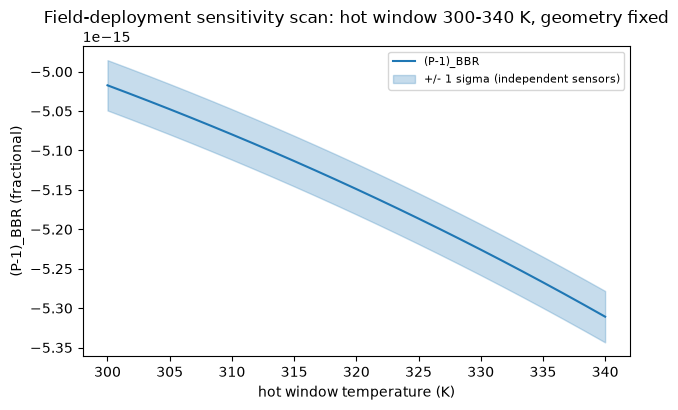

shift at T_hot=300 K:  -5.0173e-15  +/- 3.19e-17
shift at T_hot=340 K:  -5.3108e-15  +/- 3.26e-17


In [7]:
HOT_WINDOW_SCAN_K = np.linspace(300.0, 340.0, 25)
scan_shift = np.empty_like(HOT_WINDOW_SCAN_K)
scan_band = np.empty_like(HOT_WINDOW_SCAN_K)

for i, t_hot in enumerate(HOT_WINDOW_SCAN_K):
    surfaces = (
        RadiationSurface(
            name="chamber",
            weight=0.87,
            temperature_k=296.0,
            temperature_uncertainty_k=0.5,
        ),
        RadiationSurface(
            name="hot_window",
            weight=0.08,
            temperature_k=t_hot,
            temperature_uncertainty_k=1.0,
        ),
        RadiationSurface(
            name="cold_window",
            weight=0.05,
            temperature_k=285.0,
            temperature_uncertainty_k=2.0,
        ),
    )
    scan_shift[i] = bbr_environment_pivot_perturbation(surfaces, sr87)
    scan_band[i], _ = bbr_environment_pivot_uncertainty(surfaces, sr87, correlated=False)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(HOT_WINDOW_SCAN_K, scan_shift, color="C0", label="(P-1)_BBR")
ax.fill_between(
    HOT_WINDOW_SCAN_K,
    scan_shift - scan_band,
    scan_shift + scan_band,
    color="C0",
    alpha=0.25,
    label="+/- 1 sigma (independent sensors)",
)
ax.set_xlabel("hot window temperature (K)")
ax.set_ylabel("(P-1)_BBR (fractional)")
ax.set_title("Field-deployment sensitivity scan: hot window 300-340 K, geometry fixed")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"shift at T_hot=300 K:  {scan_shift[0]:+.4e}  +/- {scan_band[0]:.2e}")
print(f"shift at T_hot=340 K:  {scan_shift[-1]:+.4e}  +/- {scan_band[-1]:.2e}")

A lab or systems integrator without PTB-grade thermal engineering reads
this the same way any uncertainty budget line is read: sensor readings and
their calibration uncertainties go in, a defensible BBR shift and band come
out, with no requirement to first build a shielded enclosure or run a
finite-element thermal model. The correlated band is uniformly wider than
the independent one here, exactly as E37's derivation guarantees for
same-sign coefficient partials, and the choice between them is a statement
about the sensors themselves, whether their readings share a calibration
chain or not, not a free parameter to tune for a smaller number. The
per-moment effective temperatures diverging by roughly two-tenths of a
kelvin between `T_eff,4` and `T_eff,6` in the baseline scenario is the concrete,
numerical version of section 1's headline point, reproduced inside a single
realistic scenario instead of an abstract sweep.

## 5. What this notebook validates, and what it does not

Two things are checked against a real number and one is checked against
this project's own gate record. The PTB comparison in section 2 confirms
E37's aperture-and-enclosure weight arithmetic reproduces Nosske et al.'s
own closed form exactly, a formula-transcription validation, not an
independent test of BBR accuracy or a reconstruction of PTB's own measured
shift. The JILA comparison in section 3 confirms the registry's
temperature-dependence formula tracks a real, deliberately introduced
2.5-degree operating-temperature step, a single-point consistency anchor,
not a spatial-non-uniformity test. The multi-surface machinery itself,
additivity, the moment algebra, the enclosure-and-apertures topology, and
the uncertainty propagation, passed an independent physics and code review
at G10, including a blocker found and closed on the emissivity formula's own
reduction to PTB's two-surface case; that review is this notebook's
provenance for the machinery, not a third validation case alongside the two
above. This notebook adds no new entry to the project's reproducibility-case
count.

What is not yet validated is a full published multi-surface
thermal-environment reproduction: no lab surveyed for this work publishes a
machine-readable per-surface temperature-and-weight map alongside its own
measured shift, so there is no target to replay end to end the way
notebooks 06 and 09 replay NPL's and Bothwell's own numbers. A partner lab
willing to share that map, even informally, ahead of or alongside its own
shift measurement would make the first one; `docs/roadmap.md`'s thermal-field-maps
section and `docs/CONVENTIONS.md`'s E37 record the same open door.

In [8]:
print(f"notebook runtime: {time.time() - _notebook_start_s:.1f} s")

notebook runtime: 0.4 s
